# UrbanIQ - CityLife Score

## Objective

The CityLife Score is designed to evaluate the overall livability of different Bengaluru locations by combining housing prices with city infrastructure indicators such as metro accessibility, hospitals, schools, parks, and other amenities.

Unlike traditional housing analysis, this score helps identify locations that provide the best balance between affordability and quality of life.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv("../data/cleaned_bengaluru_housing.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/cleaned_bengaluru_housing.csv'

In [3]:
import os

print(os.getcwd())


C:\Users\sanja\UrbanIQ\notebooks


In [4]:
df = pd.read_csv("../data/cleaned_bengaluru_housing.csv")

In [5]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'cleaned_bengaluru_housing.csv', 'processed', 'raw']


In [6]:
import pandas as pd

df = pd.read_csv("../data/cleaned_bengaluru_housing.csv")

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615,650.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861,507.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000,600.0


In [7]:
# CityLife Score

## Introduction

The CityLife Score is a custom livability index developed for the UrbanIQ project.

Instead of evaluating properties based only on price, the CityLife Score considers several important urban factors such as:

- Metro Accessibility
- Hospital Availability
- School Accessibility
- Property Affordability
- Future Expansion (optional)

This score helps identify locations that offer the best overall quality of life for residents.

SyntaxError: invalid syntax (3716348589.py, line 5)

# CityLife Score

## Introduction

The CityLife Score is a custom livability index developed for the UrbanIQ project.

Instead of evaluating properties based only on price, the CityLife Score considers several important urban factors such as:

- Metro Accessibility
- Hospital Availability
- School Accessibility
- Property Affordability
- Future Expansion (optional)

This score helps identify locations that offer the best overall quality of life for residents.

## Step 1: Explore the Cleaned Housing Dataset

Before integrating additional city infrastructure datasets, we first examine the cleaned housing dataset that will serve as the foundation for calculating the CityLife Score.

In [8]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615,650.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861,507.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000,600.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11955 entries, 0 to 11954
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       11955 non-null  object 
 1   availability    11955 non-null  object 
 2   location        11955 non-null  object 
 3   size            11955 non-null  object 
 4   total_sqft      11955 non-null  float64
 5   bath            11955 non-null  float64
 6   balcony         11955 non-null  float64
 7   price           11955 non-null  float64
 8   bhk             11955 non-null  int64  
 9   price_per_sqft  11955 non-null  float64
 10  sqft_per_bhk    11955 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.0+ MB


In [10]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
count,11955.000000,11955.000000,11955.000000,11955.000000,11955.000000,11955.000000,11955.000000
mean,1606.603798,2.573818,1.603597,113.451652,2.662652,6372.777019,599.332653
std,1285.871232,1.091958,0.802395,155.058710,0.989508,4230.466327,395.209355
min,300.000000,1.000000,0.000000,9.000000,1.000000,267.829813,300.000000
25%,1116.500000,2.000000,1.000000,50.000000,2.000000,4251.834592,492.500000
50%,1306.000000,2.000000,2.000000,70.000000,3.000000,5333.333333,562.666667
75%,1715.500000,3.000000,2.000000,120.000000,3.000000,6977.315582,632.500000
max,52272.000000,16.000000,3.000000,3600.000000,16.000000,176470.588235,26136.000000


## Property Distribution by Location

Understanding the number of properties available in each location helps identify areas with higher housing activity and market concentration.

In [11]:
location_counts = df["location"].value_counts().head(15)

location_counts

location
Other                       2758
Whitefield                   520
Sarjapur  Road               373
Electronic City              280
Kanakpura Road               238
Thanisandra                  230
Yelahanka                    204
Marathahalli                 164
Hebbal                       160
Raja Rajeshwari Nagar        158
Uttarahalli                  148
Bannerghatta Road            147
Hennur Road                  145
7th Phase JP Nagar           129
Electronic City Phase II     122
Name: count, dtype: int64

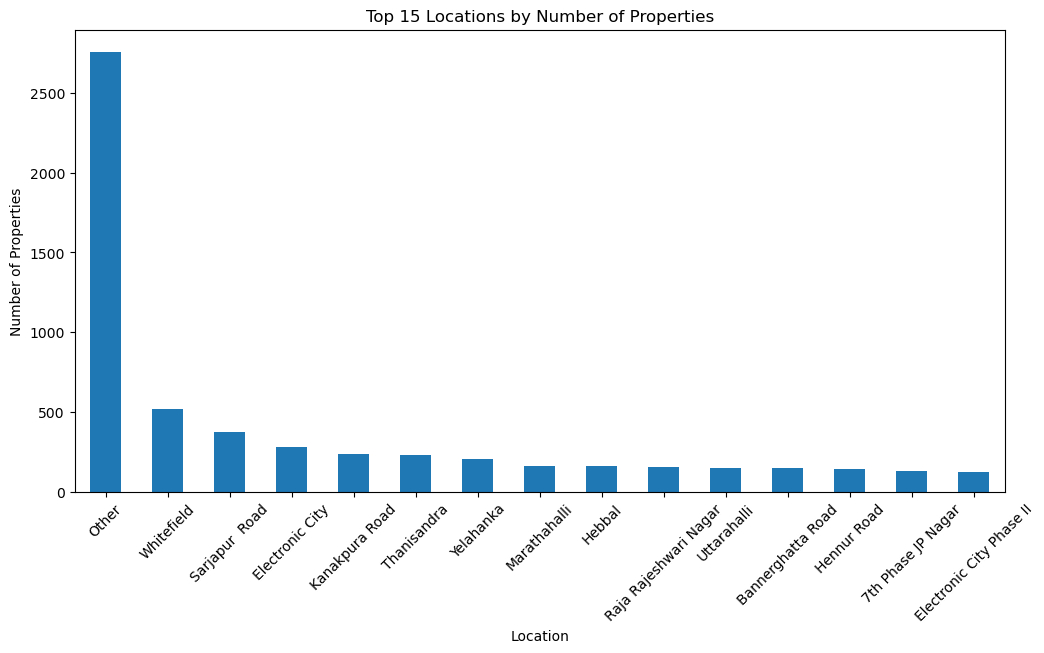

In [12]:
plt.figure(figsize=(12,6))

location_counts.plot(kind="bar")

plt.title("Top 15 Locations by Number of Properties")
plt.xlabel("Location")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.savefig("../images/location_distribution_citylife.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Business Insight

The locations with the highest number of listed properties indicate active residential markets. These locations will be prioritized while calculating the CityLife Score because they represent significant housing demand.

## Step 2: Preparing External Datasets

To calculate a meaningful CityLife Score, additional datasets containing information about metro stations, hospitals, and schools will be integrated with the housing dataset.

These datasets will help measure accessibility and improve the overall livability analysis.

In [13]:
print(df.shape)

df.head()

(11955, 11)


,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615,650.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861,507.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000,600.0


In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Total Properties",
        "Total Locations",
        "Average Price",
        "Average Price per Sqft"
    ],
    "Value": [
        len(df),
        df["location"].nunique(),
        round(df["price"].mean(), 2),
        round(df["price_per_sqft"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Properties,11955.00
1,Total Locations,215.00
2,Average Price,113.45
3,Average Price per Sqft,6372.78


### Business Insight

The housing dataset contains property listings from multiple Bengaluru locations. This dataset provides the foundation for the CityLife Score, which will be enhanced using external infrastructure datasets.

In [15]:
print(df.shape)

df.head()

(11955, 11)


,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615,650.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861,507.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000,600.0


In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Total Properties",
        "Total Locations",
        "Average Price",
        "Average Price per Sqft"
    ],
    "Value": [
        len(df),
        df["location"].nunique(),
        round(df["price"].mean(), 2),
        round(df["price_per_sqft"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Properties,11955.00
1,Total Locations,215.00
2,Average Price,113.45
3,Average Price per Sqft,6372.78


In [17]:
metro_df = pd.read_csv("../data/raw/metro/bengaluru_metro_stations.csv")

metro_df.head()

,station_name,line,latitude,longitude,location
0,Baiyappanahalli,Purple,13.0358,77.6324,Baiyappanahalli
1,Swami Vivekananda Road,Purple,13.0219,77.6357,Indiranagar
2,Indiranagar,Purple,12.9784,77.6408,Indiranagar
3,Halasuru,Purple,12.9770,77.6267,Ulsoor
4,MG Road,Purple,12.9756,77.6068,MG Road


In [18]:
# Metro dataset information

metro_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_name  14 non-null     object 
 1   line          14 non-null     object 
 2   latitude      14 non-null     float64
 3   longitude     14 non-null     float64
 4   location      14 non-null     object 
dtypes: float64(2), object(3)
memory usage: 692.0+ bytes


In [19]:
# Check metro locations

metro_df["location"].unique()

array(['Baiyappanahalli', 'Indiranagar', 'Ulsoor', 'MG Road',
       'Cubbon Park', 'Vidhana Soudha', 'Majestic', 'Yeshwanthpur',
       'Peenya', 'Nagasandra', 'Malleshwaram', 'Jayanagar',
       'Yelachenahalli'], dtype=object)

In [20]:
# Total metro stations

len(metro_df)

14

In [21]:
# Create Metro Accessibility Score

metro_locations = metro_df["location"].str.lower().unique()

def metro_score(location):
    if str(location).lower() in metro_locations:
        return 10
    else:
        return 0

metro_df["metro_score"] = metro_df["location"].apply(metro_score)

metro_df.head()

,station_name,line,latitude,longitude,location,metro_score
0,Baiyappanahalli,Purple,13.0358,77.6324,Baiyappanahalli,10
1,Swami Vivekananda Road,Purple,13.0219,77.6357,Indiranagar,10
2,Indiranagar,Purple,12.9784,77.6408,Indiranagar,10
3,Halasuru,Purple,12.9770,77.6267,Ulsoor,10
4,MG Road,Purple,12.9756,77.6068,MG Road,10


In [22]:
# Load hospital dataset

hospital_df = pd.read_csv("../data/raw/hospitals/bengaluru_hospitals.csv")

hospital_df.head()

,hospital_name,latitude,longitude,location
0,Manipal Hospital Old Airport Road,12.9592,77.6488,Old Airport Road
1,Apollo Hospital Sheshadripuram,12.9935,77.5785,Sheshadripuram
2,Narayana Health City,12.8489,77.6637,Bommasandra
3,Fortis Hospital Bannerghatta Road,12.8955,77.5987,Bannerghatta Road
4,Columbia Asia Hospital Hebbal,13.0358,77.5970,Hebbal


In [23]:
hospital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hospital_name  8 non-null      object 
 1   latitude       8 non-null      float64
 2   longitude      8 non-null      float64
 3   location       8 non-null      object 
dtypes: float64(2), object(2)
memory usage: 388.0+ bytes


In [24]:
# Create Healthcare Accessibility Score

hospital_locations = hospital_df["location"].str.lower().unique()

def hospital_score(location):
    if str(location).lower() in hospital_locations:
        return 10
    else:
        return 0

hospital_df["healthcare_score"] = hospital_df["location"].apply(hospital_score)

hospital_df.head()


,hospital_name,latitude,longitude,location,healthcare_score
0,Manipal Hospital Old Airport Road,12.9592,77.6488,Old Airport Road,10
1,Apollo Hospital Sheshadripuram,12.9935,77.5785,Sheshadripuram,10
2,Narayana Health City,12.8489,77.6637,Bommasandra,10
3,Fortis Hospital Bannerghatta Road,12.8955,77.5987,Bannerghatta Road,10
4,Columbia Asia Hospital Hebbal,13.0358,77.5970,Hebbal,10


In [25]:
# Hospital covered areas

hospital_df["location"].unique()

array(['Old Airport Road', 'Sheshadripuram', 'Bommasandra',
       'Bannerghatta Road', 'Hebbal', 'Koramangala', 'Mathikere',
       'Kalbadevi'], dtype=object)

In [26]:
# Load school dataset

school_df = pd.read_csv("../data/raw/schools/bengaluru_schools.csv")

school_df.head()

,school_name,latitude,longitude,location
0,National Public School Indiranagar,12.9784,77.6408,Indiranagar
1,Delhi Public School Bangalore East,12.9450,77.7090,Sarjapur Road
2,Bangalore International School,13.0800,77.6400,Yelahanka
3,National Academy For Learning,12.8900,77.5850,Bannerghatta Road
4,St Josephs Boys High School,12.9700,77.6000,MG Road


In [27]:
school_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   school_name  8 non-null      object 
 1   latitude     8 non-null      float64
 2   longitude    8 non-null      float64
 3   location     8 non-null      object 
dtypes: float64(2), object(2)
memory usage: 388.0+ bytes


In [28]:
# Create Education Accessibility Score

school_locations = school_df["location"].str.lower().unique()

def school_score(location):
    if str(location).lower() in school_locations:
        return 10
    else:
        return 0

school_df["education_score"] = school_df["location"].apply(school_score)

school_df.head()

,school_name,latitude,longitude,location,education_score
0,National Public School Indiranagar,12.9784,77.6408,Indiranagar,10
1,Delhi Public School Bangalore East,12.9450,77.7090,Sarjapur Road,10
2,Bangalore International School,13.0800,77.6400,Yelahanka,10
3,National Academy For Learning,12.8900,77.5850,Bannerghatta Road,10
4,St Josephs Boys High School,12.9700,77.6000,MG Road,10


In [29]:
# School covered areas

school_df["location"].unique()

array(['Indiranagar', 'Sarjapur Road', 'Yelahanka', 'Bannerghatta Road',
       'MG Road', 'Koramangala', 'Richmond Road'], dtype=object)

In [30]:
# Load air quality dataset

air_df = pd.read_csv("../data/raw/air_quality/bengaluru_air_quality.csv")

air_df.head()

,location,aqi,pm25,pm10
0,Indiranagar,65,32,70
1,Koramangala,58,28,60
2,Whitefield,92,45,110
3,Electronic City,75,38,85
4,Yelahanka,55,25,55


In [31]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   location  8 non-null      object
 1   aqi       8 non-null      int64 
 2   pm25      8 non-null      int64 
 3   pm10      8 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 388.0+ bytes


In [32]:
# Create Environment Score

def environment_score(aqi):
    if aqi <= 60:
        return 10
    elif aqi <= 80:
        return 7
    else:
        return 5

air_df["environment_score"] = air_df["aqi"].apply(environment_score)

air_df.head()

,location,aqi,pm25,pm10,environment_score
0,Indiranagar,65,32,70,7
1,Koramangala,58,28,60,10
2,Whitefield,92,45,110,5
3,Electronic City,75,38,85,7
4,Yelahanka,55,25,55,10


In [33]:
air_df[["location", "aqi", "environment_score"]]

,location,aqi,environment_score
0,Indiranagar,65,7
1,Koramangala,58,10
2,Whitefield,92,5
3,Electronic City,75,7
4,Yelahanka,55,10
5,Hebbal,70,7
6,MG Road,80,7
7,Bannerghatta Road,60,10


In [34]:
# Load traffic dataset

traffic_df = pd.read_csv("../data/raw/traffic/bengaluru_traffic.csv")

traffic_df.head()

,location,traffic_level,avg_delay_minutes
0,Whitefield,High,45
1,Electronic City,High,50
2,Silk Board,High,55
3,Marathahalli,High,40
4,Indiranagar,Medium,25


In [35]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   location           10 non-null     object
 1   traffic_level      10 non-null     object
 2   avg_delay_minutes  10 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


In [36]:
# Create Traffic Score

def traffic_score(level):
    if level == "Low":
        return 10
    elif level == "Medium":
        return 7
    else:
        return 4

traffic_df["traffic_score"] = traffic_df["traffic_level"].apply(traffic_score)

traffic_df.head()

,location,traffic_level,avg_delay_minutes,traffic_score
0,Whitefield,High,45,4
1,Electronic City,High,50,4
2,Silk Board,High,55,4
3,Marathahalli,High,40,4
4,Indiranagar,Medium,25,7


In [37]:
traffic_df[["location", "traffic_level", "traffic_score"]]

,location,traffic_level,traffic_score
0,Whitefield,High,4
1,Electronic City,High,4
2,Silk Board,High,4
3,Marathahalli,High,4
4,Indiranagar,Medium,7
5,Koramangala,Medium,7
6,Yelahanka,Low,10
7,Hebbal,Medium,7
8,MG Road,Medium,7
9,Bannerghatta Road,High,4


In [38]:
# Create master location list

locations = set()

locations.update(metro_df["location"])
locations.update(hospital_df["location"])
locations.update(school_df["location"])
locations.update(air_df["location"])
locations.update(traffic_df["location"])

city_df = pd.DataFrame({"location": list(locations)})

city_df.head()

,location
0,Vidhana Soudha
1,Yeshwanthpur
2,Silk Board
3,Ulsoor
4,Bannerghatta Road


In [39]:
city_df.shape

(28, 1)

In [40]:
# Merge Metro Score

city_df = city_df.merge(
    metro_df[["location", "metro_score"]],
    on="location",
    how="left"
)

city_df.head()

,location,metro_score
0,Vidhana Soudha,10.0
1,Yeshwanthpur,10.0
2,Silk Board,NaN
3,Ulsoor,10.0
4,Bannerghatta Road,NaN


In [41]:
# Merge Healthcare Score

city_df = city_df.merge(
    hospital_df[["location", "healthcare_score"]],
    on="location",
    how="left"
)

city_df.head()

,location,metro_score,healthcare_score
0,Vidhana Soudha,10.0,NaN
1,Yeshwanthpur,10.0,NaN
2,Silk Board,NaN,NaN
3,Ulsoor,10.0,NaN
4,Bannerghatta Road,NaN,10.0


In [42]:
# Merge Education Score

city_df = city_df.merge(
    school_df[["location", "education_score"]],
    on="location",
    how="left"
)

city_df.head()

,location,metro_score,healthcare_score,education_score
0,Vidhana Soudha,10.0,NaN,NaN
1,Yeshwanthpur,10.0,NaN,NaN
2,Silk Board,NaN,NaN,NaN
3,Ulsoor,10.0,NaN,NaN
4,Bannerghatta Road,NaN,10.0,10.0


In [43]:
# Merge Environment Score

city_df = city_df.merge(
    air_df[["location", "environment_score"]],
    on="location",
    how="left"
)

city_df.head()

,location,metro_score,healthcare_score,education_score,environment_score
0,Vidhana Soudha,10.0,NaN,NaN,NaN
1,Yeshwanthpur,10.0,NaN,NaN,NaN
2,Silk Board,NaN,NaN,NaN,NaN
3,Ulsoor,10.0,NaN,NaN,NaN
4,Bannerghatta Road,NaN,10.0,10.0,10.0


In [44]:
# Merge Traffic Score

city_df = city_df.merge(
    traffic_df[["location", "traffic_score"]],
    on="location",
    how="left"
)

city_df.head()

,location,metro_score,healthcare_score,education_score,environment_score,traffic_score
0,Vidhana Soudha,10.0,NaN,NaN,NaN,NaN
1,Yeshwanthpur,10.0,NaN,NaN,NaN,NaN
2,Silk Board,NaN,NaN,NaN,NaN,4.0
3,Ulsoor,10.0,NaN,NaN,NaN,NaN
4,Bannerghatta Road,NaN,10.0,10.0,10.0,4.0


In [45]:
city_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location           30 non-null     object 
 1   metro_score        14 non-null     float64
 2   healthcare_score   8 non-null      float64
 3   education_score    9 non-null      float64
 4   environment_score  10 non-null     float64
 5   traffic_score      12 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.5+ KB


In [46]:
# Fill missing scores

city_df = city_df.fillna(0)

city_df.head()

,location,metro_score,healthcare_score,education_score,environment_score,traffic_score
0,Vidhana Soudha,10.0,0.0,0.0,0.0,0.0
1,Yeshwanthpur,10.0,0.0,0.0,0.0,0.0
2,Silk Board,0.0,0.0,0.0,0.0,4.0
3,Ulsoor,10.0,0.0,0.0,0.0,0.0
4,Bannerghatta Road,0.0,10.0,10.0,10.0,4.0


In [47]:
# Calculate final CityLife Score

score_columns = [
    "metro_score",
    "healthcare_score",
    "education_score",
    "environment_score",
    "traffic_score"
]

city_df["citylife_score"] = city_df[score_columns].mean(axis=1)

city_df.head()

,location,metro_score,healthcare_score,education_score,environment_score,traffic_score,citylife_score
0,Vidhana Soudha,10.0,0.0,0.0,0.0,0.0,2.0
1,Yeshwanthpur,10.0,0.0,0.0,0.0,0.0,2.0
2,Silk Board,0.0,0.0,0.0,0.0,4.0,0.8
3,Ulsoor,10.0,0.0,0.0,0.0,0.0,2.0
4,Bannerghatta Road,0.0,10.0,10.0,10.0,4.0,6.8


In [48]:
# Rank locations

city_df = city_df.sort_values(
    by="citylife_score",
    ascending=False
)

city_df.head(10)

,location,metro_score,healthcare_score,education_score,environment_score,traffic_score,citylife_score
20,Koramangala,0.0,10.0,10.0,10.0,7.0,7.4
4,Bannerghatta Road,0.0,10.0,10.0,10.0,4.0,6.8
10,Indiranagar,10.0,0.0,10.0,7.0,7.0,6.8
11,Indiranagar,10.0,0.0,10.0,7.0,7.0,6.8
13,MG Road,10.0,0.0,10.0,7.0,7.0,6.8
23,Yelahanka,0.0,0.0,10.0,10.0,10.0,6.0
22,Yelahanka,0.0,0.0,10.0,10.0,10.0,6.0
18,Hebbal,0.0,10.0,0.0,7.0,7.0,4.8
24,Electronic City,0.0,0.0,0.0,7.0,4.0,2.2
0,Vidhana Soudha,10.0,0.0,0.0,0.0,0.0,2.0


In [49]:
# Remove duplicate locations

city_df = city_df.groupby("location", as_index=False).mean()

# Sort again

city_df = city_df.sort_values(
    by="citylife_score",
    ascending=False
)

city_df.head(10)

,location,metro_score,healthcare_score,education_score,environment_score,traffic_score,citylife_score
9,Koramangala,0.0,10.0,10.0,10.0,7.0,7.4
6,Indiranagar,10.0,0.0,10.0,7.0,7.0,6.8
10,MG Road,10.0,0.0,10.0,7.0,7.0,6.8
1,Bannerghatta Road,0.0,10.0,10.0,10.0,4.0,6.8
26,Yelahanka,0.0,0.0,10.0,10.0,10.0,6.0
5,Hebbal,0.0,10.0,0.0,7.0,7.0,4.8
4,Electronic City,0.0,0.0,0.0,7.0,4.0,2.2
0,Baiyappanahalli,10.0,0.0,0.0,0.0,0.0,2.0
16,Old Airport Road,0.0,10.0,0.0,0.0,0.0,2.0
25,Yelachenahalli,10.0,0.0,0.0,0.0,0.0,2.0


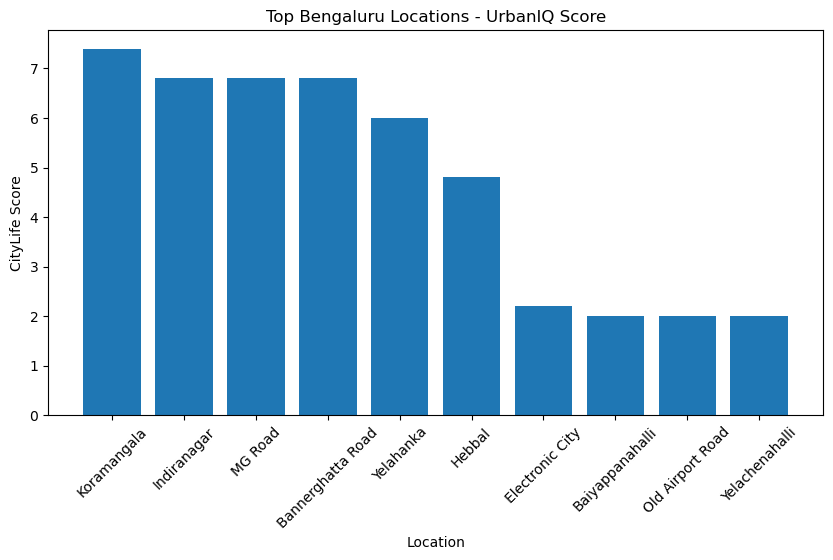

In [50]:
import matplotlib.pyplot as plt

top_locations = city_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_locations["location"],
    top_locations["citylife_score"]
)

plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("CityLife Score")
plt.title("Top Bengaluru Locations - UrbanIQ Score")

plt.show()

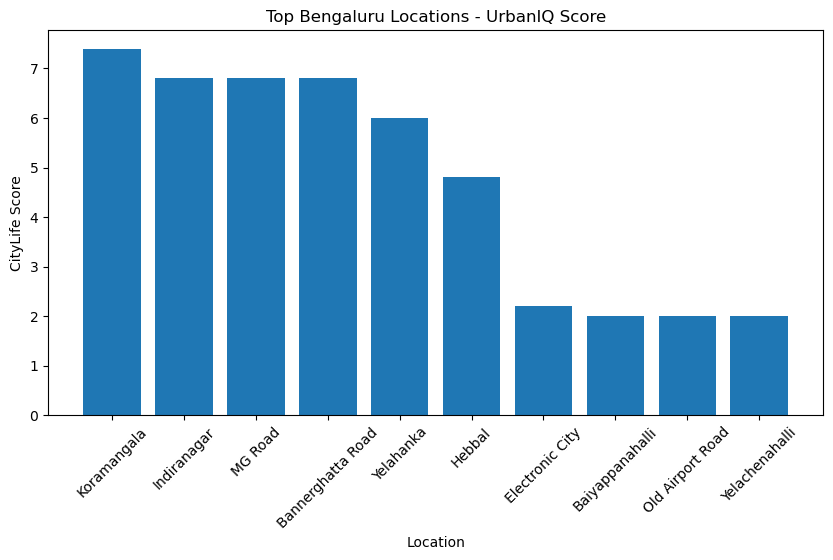

In [51]:
import matplotlib.pyplot as plt

top_locations = city_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_locations["location"],
    top_locations["citylife_score"]
)

plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("CityLife Score")
plt.title("Top Bengaluru Locations - UrbanIQ Score")

# Save graph
plt.savefig("../images/citylife_score.png", bbox_inches="tight")

plt.show()